### Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [53]:
# fetch dataset 
multivariate_gait_data = fetch_ucirepo(id=760)

In [54]:
# store data in two formats
long = multivariate_gait_data.data.features
wide = long.pivot_table(index=["subject", "replication", "time", "condition"], columns=["leg", "joint"])

In [57]:
# randomly select training/testing subjects (80/20 split)
# split data by subjects to avoid data leakage
train_subjects = random.sample(range(1, 11), 8)
test_subjects = [i for i in range(1, 11) if i not in train_subjects]

In [58]:
# split training/testing data (long)
train_long = long[long["subject"].isin(train_subjects)]
test_long = long[long["subject"].isin(test_subjects)]

X_train_long = train_long.drop(["condition"], axis=1)
y_train_long = train_long["condition"]

X_test_long = test_long.drop(["condition"], axis=1)
y_test_long = test_long["condition"]

In [79]:
# select stats to use as features
stats = ["mean", "std", "skew", "min", "max"]

# raw stats
raw_stats = wide.groupby(["subject", "replication", "condition"]).agg(stats)

# differential stats
raw_diffs = wide.groupby(["subject", "replication", "condition"]).diff().dropna()
diffs_stats = raw_diffs.groupby(["subject", "replication", "condition"]).agg(stats)

# raw and differential stats
full_stats = pd.concat([raw_stats, diffs_stats], axis=1)

# quarter stats
quarter_df = wide.copy()
quarter_df["quarter"] = pd.cut(
    quarter_df.index.get_level_values("time"),
    bins=[0, 25, 50, 75, 100],
    labels=["q1", "q2", "q3", "q4"],
    include_lowest=True
    )
quarter_stats = quarter_df.groupby(["subject", "replication", "condition", "quarter"]).agg(stats)

In [78]:
def train_test_split_wide(df, train_subjects, test_subjects):
    """ Performs train test split for the wide DataFrames """
    train = df[df.index.get_level_values("subject").isin(train_subjects)]
    test = df[df.index.get_level_values("subject").isin(test_subjects)]

    X_train = train.droplevel("condition")
    y_train = pd.Series(train.index.get_level_values("condition"))

    X_test = test.droplevel("condition")
    y_test = pd.Series(test.index.get_level_values("condition"))

    return X_train, X_test, y_train, y_test

### PCA -> SVM on raw + differential stats

In [ ]:
# split training/testing data
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split_wide(full_stats, train_subjects, test_subjects)

# scale the data
scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test_full = scaler.transform(X_test_full)

Text(0.5, 1.0, 'Number of PCA Components vs. Explained Variance')

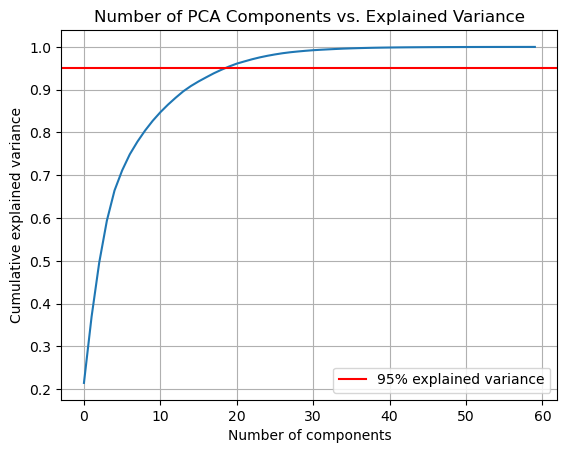

In [117]:
# plot a graph to figure out the optimal number of PCA components
pca = PCA().fit(X_train_full)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.95, color="red", label="95% explained variance")
plt.legend()
plt.grid(True)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Number of PCA Components vs. Explained Variance")

In [125]:
# identify the specific number of components
opt_n = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95)
print(f"Optimal number of PCA components: {opt_n}")

Optimal number of PCA components: 19


In [ ]:
# apply PCA
pca = PCA(n_components=19)
X_train_full_pca = pca.fit_transform(X_train_full)
X_test_full_pca = pca.transform(X_test_full)

In [142]:
svm = SVC()
svm.fit(X_train_full_pca, y_train_full)
accuracy = svm.score(X_test_full_pca, y_test_full)
print(f"Accuracy: {accuracy}")

Accuracy: 1.0


An accuracy of 1.0 indicates overfitting. It's possible this is caused by data leakage, a small dataset, or another factor.